# Issue #8 — LightGBM Classifier
## Tercer estimador del ensemble — Clasificación Multiclase de Incontinencia Urinaria

Este notebook entrena y optimiza el clasificador LightGBM
como tercer estimador del ensemble.

Parte de los archivos generados por `02_pipeline_clean.ipynb`.

| Paso | Acción |
|------|--------|
| 1 | Carga de datos del pipeline limpio |
| 2 | Baseline con CV honesta (SMOTE dentro de cada fold) |
| 3 | Optimización de hiperparámetros con Optuna |
| 4 | Comparativa baseline vs tuneado |
| 5 | Métricas finales con foco en clase `urgencia` |
| 6 | Guardado del modelo en `models/lgbm.pkl` |


## 0. Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings("ignore")

from lightgbm import LGBMClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

PALETTE = {
    'none':   '#ADB5BD',
    'stress': '#4C9BE8',
    'mixed':  '#F4A261',
    'urge':   '#E63946',
}

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## Paso 1 — Carga de datos del pipeline limpio

Cargamos los archivos generados por `02_pipeline_clean.ipynb`.
Estos datos ya están escalados, sin SMOTE y sin variables leaky.


In [2]:
X_train = pd.read_csv("../data/processed/X_train_clean.csv")
y_train = pd.read_csv("../data/processed/y_train_clean.csv").squeeze()
X_test  = pd.read_csv("../data/processed/X_test_clean.csv")
y_test  = pd.read_csv("../data/processed/y_test_clean.csv").squeeze()

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")

print(f"\nDistribución en train (sin SMOTE — distribución real):")
print((y_train.value_counts(normalize=True) * 100).round(1))

print(f"\nDistribución en test (distribución real):")
print((y_test.value_counts(normalize=True) * 100).round(1))


X_train: (7259, 21)  |  y_train: (7259,)
X_test:  (1815, 21)   |  y_test:  (1815,)

Distribución en train (sin SMOTE — distribución real):
target_tipo_ui
none      53.5
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64

Distribución en test (distribución real):
target_tipo_ui
none      53.6
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64


## Paso 2 — Baseline LightGBM con CV honesta

Usamos `ImbPipeline` para que el SMOTE se aplique **dentro de cada fold**
de la validación cruzada.

**Flujo dentro de cada fold:**
1. Datos de train del fold (datos reales) → SMOTE → datos balanceados
2. LightGBM entrena con datos balanceados
3. Evalúa sobre el fold de validación (datos reales, sin sintéticos)

Así las métricas de CV reflejan el rendimiento real del modelo.


In [3]:
pipeline_baseline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbm',  LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline_baseline,
    X_train, y_train,
    cv=skf,
    scoring={
        'accuracy':    'accuracy',
        'f1_macro':    'f1_macro',
        'f1_weighted': 'f1_weighted'
    },
    n_jobs=-1
)

baseline_accuracy = cv_results['test_accuracy'].mean()
baseline_f1_macro = cv_results['test_f1_macro'].mean()

print("=" * 55)
print("BASELINE — Validación cruzada 5-fold (CV honesta)")
print("=" * 55)
print(f"\nAccuracy:    {baseline_accuracy:.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"F1-macro:    {baseline_f1_macro:.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"F1-weighted: {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")


BASELINE — Validación cruzada 5-fold (CV honesta)

Accuracy:    0.6385 ± 0.0014
F1-macro:    0.4907 ± 0.0076
F1-weighted: 0.6207 ± 0.0027


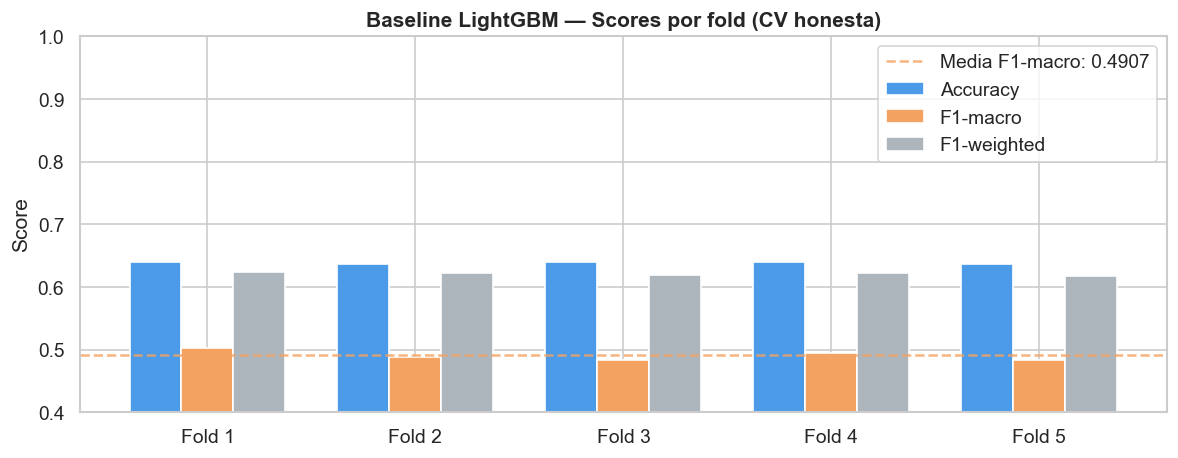

In [4]:
# Visualización scores por fold
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(5)
width = 0.25
ax.bar(x - width, cv_results['test_accuracy'],    width, label='Accuracy',    color='#4C9BE8', edgecolor='white')
ax.bar(x,         cv_results['test_f1_macro'],    width, label='F1-macro',    color='#F4A261', edgecolor='white')
ax.bar(x + width, cv_results['test_f1_weighted'], width, label='F1-weighted', color='#ADB5BD', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Score')
ax.set_title('Baseline LightGBM — Scores por fold (CV honesta)', fontweight='bold')
ax.axhline(baseline_f1_macro, color='#F4A261', ls='--', lw=1.5,
           alpha=0.8, label=f'Media F1-macro: {baseline_f1_macro:.4f}')
ax.legend()

plt.tight_layout()
plt.show()


In [5]:
# Baseline en test
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

lgbm_base = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_base.fit(X_train_bal, y_train_bal)
y_pred_baseline = lgbm_base.predict(X_test)

train_acc_base = accuracy_score(y_train_bal, lgbm_base.predict(X_train_bal))
test_acc_base  = accuracy_score(y_test, y_pred_baseline)

print("Baseline — Métricas en test:")
print(classification_report(y_test, y_pred_baseline))
print(f"Overfitting: {(train_acc_base - test_acc_base)*100:.2f}%  {'✅ < 5%' if (train_acc_base - test_acc_base)*100 < 5 else '⚠️ > 5%'}")


Baseline — Métricas en test:
              precision    recall  f1-score   support

       mixed       0.53      0.48      0.50       328
        none       0.75      0.88      0.81       972
      stress       0.43      0.35      0.38       317
        urge       0.29      0.17      0.21       198

    accuracy                           0.64      1815
   macro avg       0.50      0.47      0.48      1815
weighted avg       0.60      0.64      0.61      1815

Overfitting: 19.00%  ⚠️ > 5%


## Paso 3 — Optimización de hiperparámetros con Optuna

Optuna busca los mejores hiperparámetros usando un algoritmo bayesiano.
La métrica objetivo es **F1-macro** para que todas las clases,
incluyendo `urgencia`, sean igualmente importantes.

El SMOTE sigue aplicándose dentro de cada fold durante la CV.

**Hiperparámetros a optimizar:**
- `num_leaves` → complejidad del árbol
- `learning_rate` → velocidad de aprendizaje
- `n_estimators` → número de árboles
- `min_child_samples` → mínimo de muestras por hoja (controla overfitting)


In [ ]:
def objective(trial):
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'class_weight':      'balanced',
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
    }

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('lgbm',  LGBMClassifier(**params))
    ])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline,
        X_train, y_train,
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1
    )
    return scores.mean()

print("Iniciando optimización con Optuna (50 trials)...")
print("Esto puede tardar unos minutos...\n")

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Optimización completada")
print(f"Mejor F1-macro CV: {study.best_value:.4f}")
print(f"Mejores parámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


Iniciando optimización con Optuna (50 trials)...
Esto puede tardar unos minutos...



  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
# Visualización de la optimización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optuna — Optimización de hiperparámetros LightGBM', fontweight='bold')

trials_values = [t.value for t in study.trials]
best_so_far   = [max(trials_values[:i+1]) for i in range(len(trials_values))]

axes[0].plot(trials_values, alpha=0.4, color='#ADB5BD', label='Trial')
axes[0].plot(best_so_far,   color='#E63946', lw=2, label='Mejor hasta ahora')
axes[0].axhline(baseline_f1_macro, color='#4C9BE8', ls='--', lw=1.5,
                label=f'Baseline ({baseline_f1_macro:.4f})')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('F1-macro')
axes[0].set_title('Evolución de la optimización')
axes[0].legend()

try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()),
                 color='#4C9BE8', edgecolor='white')
    axes[1].set_title('Importancia de hiperparámetros')
    axes[1].set_xlabel('Importancia relativa')
except:
    axes[1].text(0.5, 0.5, 'No disponible', ha='center', va='center')

plt.tight_layout()
plt.show()


## Paso 4 — Comparativa baseline vs modelo tuneado

In [ ]:
best_params = study.best_params.copy()
best_params.update({
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs':       -1,
    'verbose':      -1
})

pipeline_tuned = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbm',  LGBMClassifier(**best_params))
])

cv_tuned = cross_validate(
    pipeline_tuned,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        'accuracy':    'accuracy',
        'f1_macro':    'f1_macro',
        'f1_weighted': 'f1_weighted'
    },
    n_jobs=-1
)

tuned_f1_macro = cv_tuned['test_f1_macro'].mean()
tuned_accuracy = cv_tuned['test_accuracy'].mean()

print("=" * 60)
print("COMPARATIVA — Baseline vs Tuneado (CV honesta 5-fold)")
print("=" * 60)
print(f"\n{'Métrica':<20} {'Baseline':>12} {'Tuneado':>12} {'Mejora':>10}")
print("-" * 60)
print(f"{'Accuracy':<20} {baseline_accuracy:>12.4f} {tuned_accuracy:>12.4f} {(tuned_accuracy-baseline_accuracy)*100:>+9.2f}%")
print(f"{'F1-macro':<20} {baseline_f1_macro:>12.4f} {tuned_f1_macro:>12.4f} {(tuned_f1_macro-baseline_f1_macro)*100:>+9.2f}%")


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

metricas      = ['Accuracy', 'F1-macro', 'F1-weighted']
baseline_vals = [baseline_accuracy, baseline_f1_macro, cv_results['test_f1_weighted'].mean()]
tuned_vals    = [tuned_accuracy, tuned_f1_macro, cv_tuned['test_f1_weighted'].mean()]

x     = np.arange(len(metricas))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='#ADB5BD', edgecolor='white')
bars2 = ax.bar(x + width/2, tuned_vals,   width, label='Tuneado',  color='#E63946', edgecolor='white')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuneado — CV honesta 5-fold', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


## Paso 5 — Métricas finales con foco en clase `urgencia`

Entrenamos el modelo tuneado con SMOTE sobre todo el train
y evaluamos en test con datos reales.


In [ ]:
lgbm_tuned = LGBMClassifier(**best_params)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
lgbm_tuned.fit(X_train_bal, y_train_bal)

y_pred_tuned = lgbm_tuned.predict(X_test)

train_acc   = accuracy_score(y_train_bal, lgbm_tuned.predict(X_train_bal))
test_acc    = accuracy_score(y_test, y_pred_tuned)
overfitting = (train_acc - test_acc) * 100

print("=" * 55)
print("MÉTRICAS FINALES — Modelo Tuneado en Test")
print("=" * 55)
print(f"\nAccuracy train: {train_acc:.4f}")
print(f"Accuracy test:  {test_acc:.4f}")
print(f"Overfitting:    {overfitting:.2f}%  {'✅ < 5%' if overfitting < 5 else '⚠️ > 5%'}")
print("\n" + classification_report(y_test, y_pred_tuned))


In [ ]:
# Foco en clase urgencia
report = classification_report(y_test, y_pred_tuned, output_dict=True)

print("=" * 55)
print("FOCO EN CLASE URGENCIA")
print("=" * 55)

if 'urge' in report:
    urge = report['urge']
    print(f"\nPrecision:  {urge['precision']:.4f}")
    print(f"Recall:     {urge['recall']:.4f}")
    print(f"F1-score:   {urge['f1-score']:.4f}")
    print(f"Support:    {int(urge['support'])} casos en test")
    print(f"\n→ De cada 100 casos que predigo como urgencia, {urge['precision']*100:.1f} son correctos")
    print(f"→ De todos los casos reales de urgencia, detecto el {urge['recall']*100:.1f}%")


In [ ]:
# Matriz de confusión y F1 por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LightGBM Tuneado — Evaluación en Test', fontweight='bold')

clases_orden = [c for c in ['none', 'stress', 'mixed', 'urge'] if c in y_test.unique()]
cm = confusion_matrix(y_test, y_pred_tuned, labels=clases_orden)
ConfusionMatrixDisplay(cm, display_labels=clases_orden).plot(
    ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title('Matriz de confusión')

f1_por_clase = {cls: report[cls]['f1-score'] for cls in clases_orden if cls in report}
colores = [PALETTE.get(c, '#ADB5BD') for c in f1_por_clase]
bars = axes[1].bar(f1_por_clase.keys(), f1_por_clase.values(),
                   color=colores, edgecolor='white')
for bar, val in zip(bars, f1_por_clase.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1-score por clase')
axes[1].axhline(report['macro avg']['f1-score'], color='gray', ls='--', lw=1.5,
                label=f"F1-macro: {report['macro avg']['f1-score']:.3f}")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Análisis de errores — ¿con qué confunde urgencia?
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred_tuned)

mask_urge  = y_test_arr == 'urge'
urge_preds = y_pred_arr[mask_urge]

print("Cuando el caso real es URGENCIA, el modelo predice:")
for cls, count in pd.Series(urge_preds).value_counts().items():
    pct   = count / mask_urge.sum() * 100
    icono = "✅" if cls == 'urge' else "❌"
    print(f"  {icono} {cls:<10} {count:>4} veces ({pct:.1f}%)")


## Paso 6 — Guardado del modelo

In [ ]:
os.makedirs("../models", exist_ok=True)

joblib.dump(lgbm_tuned, "../models/lgbm.pkl")

print("✅ Modelo guardado en models/lgbm.pkl")
print(f"\nParámetros del modelo tuneado:")
for k, v in lgbm_tuned.get_params().items():
    if v is not None and k not in ['n_jobs', 'verbose', 'random_state']:
        print(f"  {k}: {v}")


## Resumen — Issue #8 LightGBM

| Paso | Acción | Estado |
|------|--------|--------|
| 1 | Carga datos del pipeline limpio | ✅ |
| 2 | Baseline con CV honesta (SMOTE en cada fold) | ✅ |
| 3 | Optimización con Optuna (50 trials, F1-macro) | ✅ |
| 4 | Comparativa baseline vs tuneado | ✅ |
| 5 | Métricas finales con foco en `urgencia` | ✅ |
| 6 | Modelo guardado en `models/lgbm.pkl` | ✅ |

**Archivo generado:** `models/lgbm.pkl` — listo para el ensemble.
